# Customer Churn Prediction – Classification Model

This project builds a Machine Learning classification model to predict whether a customer will churn (leave the service) or stay.

The project demonstrates a complete ML workflow including data preprocessing, model training, evaluation using classification metrics, and model saving for deployment.

## Step 1 – Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, roc_auc_score

import matplotlib.pyplot as plt
import seaborn as sns

import pickle

## Step 2 – Load Dataset

In [2]:
data = pd.read_csv("churn_data.csv")

data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 3 – Dataset Information

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Step 4 – Data Preprocessing

The **TotalCharges** column is stored as text in the dataset.
We convert it into numeric values so it can be used for machine learning.

If any values cannot be converted, they are replaced with **NaN** and removed.

In [4]:
# Convert TotalCharges to numeric
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

# Check missing values before cleaning
print("Missing values before cleaning:")
print(data.isnull().sum())

# Remove missing values
data = data.dropna()

# Check missing values after cleaning
print("\nMissing values after cleaning:")
print(data.isnull().sum())

Missing values before cleaning:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Missing values after cleaning:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0


## Step 5 – Encode Target Variable

The **Churn** column indicates whether a customer left the service.

Yes → Customer churned  
No → Customer stayed

Machine learning models require numerical values, so we convert:

Yes → 1  
No → 0

In [5]:
# Reload dataset to ensure a clean starting point
data = pd.read_csv("churn_data.csv")

# Remove spaces
data["Churn"] = data["Churn"].astype(str).str.strip()

# Convert Yes/No to numeric
data["Churn"] = data["Churn"].map({"No":0, "Yes":1})

# Check distribution
data["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [6]:
# Convert TotalCharges to numeric
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

# Remove rows with missing values
data = data.dropna()

# Check data types again
print(data.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


## Step 6 – Select Features and Target

We select important numerical features that influence churn:

- tenure
- MonthlyCharges
- TotalCharges

The target variable is **Churn**.

In [7]:
X = data[["tenure", "MonthlyCharges", "TotalCharges"]]
y = data["Churn"]

X.head()

,tenure,MonthlyCharges,TotalCharges
0,1,29.85,29.85
1,34,56.95,1889.50
2,2,53.85,108.15
3,45,42.30,1840.75
4,2,70.70,151.65


## Step 7 – Train Test Split

The dataset is divided into:

- Training data (80%)
- Testing data (20%)

Training data is used to train the model, while testing data evaluates performance.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (5625, 3)
Test set shape: (1407, 3)


In [9]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

## Step 9 – Predictions

The trained model predicts churn for the test dataset.

In [10]:
y_pred = model.predict(X_test)

y_pred[:10]

array([0, 0, 1, 0, 0, 0, 0, 1, 0, 0], dtype=int64)

## Step 10 – Confusion Matrix

The confusion matrix shows how many predictions were correct or incorrect.

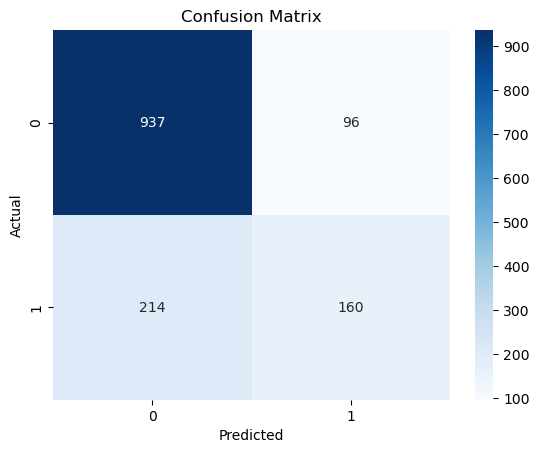

In [11]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

## Step 11 – Classification Report

The classification report provides important metrics:

- Precision
- Recall
- F1-score
- Accuracy

In [12]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.91      0.86      1033
           1       0.62      0.43      0.51       374

    accuracy                           0.78      1407
   macro avg       0.72      0.67      0.68      1407
weighted avg       0.76      0.78      0.76      1407



## Step 12 – ROC Curve

The ROC curve shows the model’s ability to distinguish between churn and non-churn customers.

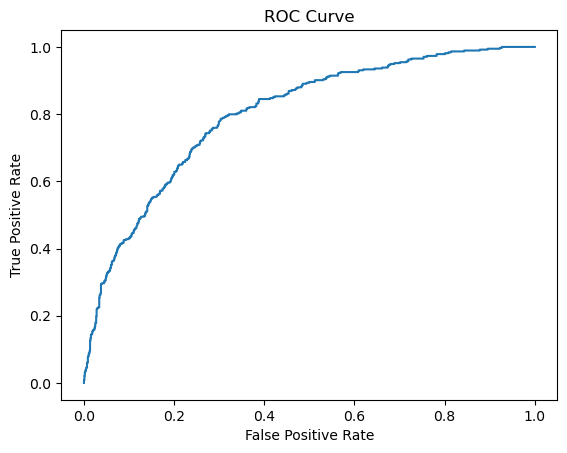

In [13]:
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

## Conclusion

This project built a Logistic Regression model to predict customer churn using key customer features such as tenure, monthly charges, and total charges.

The model was evaluated using classification metrics including the confusion matrix, precision, recall, F1-score, and ROC curve to assess prediction performance.

This analysis demonstrates how machine learning can help businesses identify customers likely to churn and support data-driven decision making for customer retention strategies.